In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
import warnings
warnings.filterwarnings('ignore')

data_path = '/kaggle/input/mai-ml-lab-2-fiit-2025'
train_df = pd.read_csv(f'{data_path}/train_c.csv')
test_df = pd.read_csv(f'{data_path}/test_c.csv')

ex_df = pd.read_csv(f'{data_path}/ex_c.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Ex shape: {ex_df.shape}")
print("\nПервые строки train:")
train_df.head()

Train shape: (11017, 35)
Test shape: (5000, 35)
Ex shape: (5000, 2)

Первые строки train:


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0


In [6]:
train_df.columns

Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved'],
      dtype='object')

In [7]:
test_df.columns

Index(['ID', 'ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio'],
      dtype='object')

In [8]:
print(train_df.info())
print(train_df.describe())
print(train_df.isnull().sum())
print(train_df['LoanApproved'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

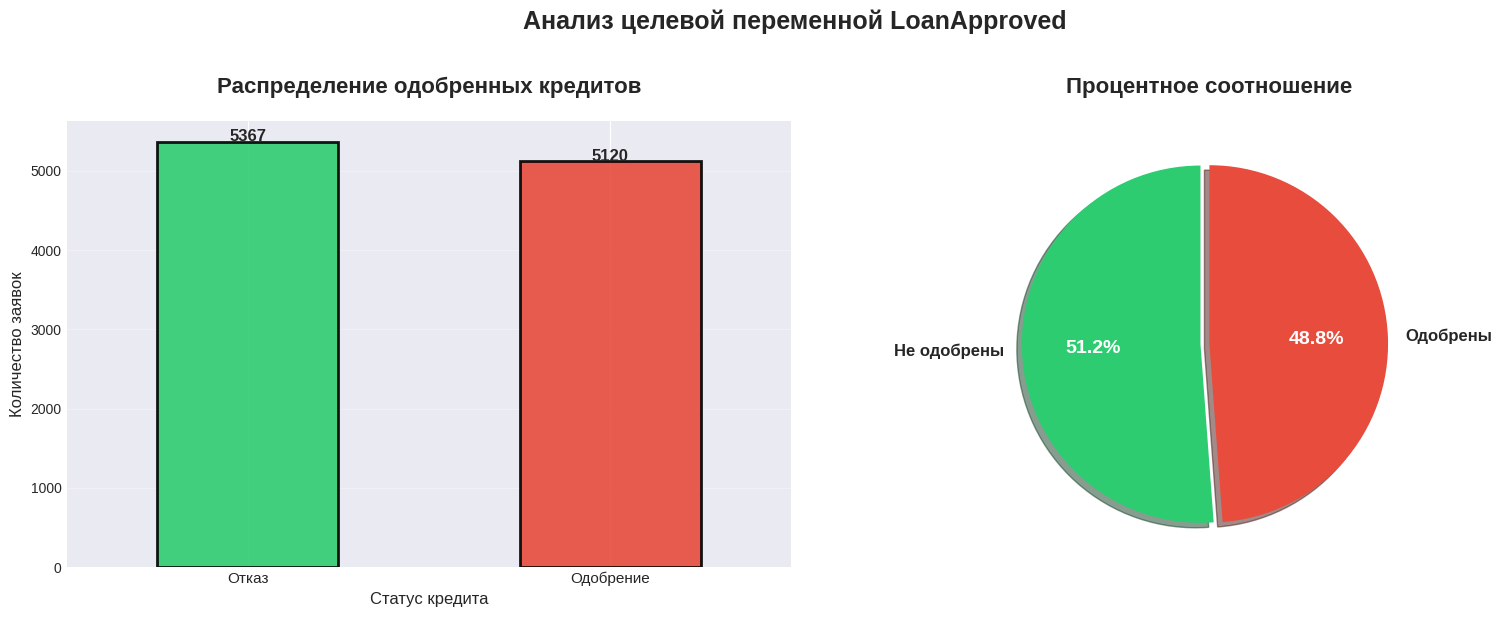

In [9]:
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2ecc71', '#e74c3c']
train_df['LoanApproved'].value_counts().plot(
    kind='bar', 
    ax=axes[0], 
    color=colors,
    edgecolor='black',
    linewidth=2,
    alpha=0.9
)
axes[0].set_title('Распределение одобренных кредитов', fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel('Статус кредита', fontsize=12)
axes[0].set_ylabel('Количество заявок', fontsize=12)
axes[0].set_xticklabels(['Отказ', 'Одобрение'], rotation=0, fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(train_df['LoanApproved'].value_counts().values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    train_df['LoanApproved'].value_counts(normalize=True),
    labels=['Не одобрены', 'Одобрены'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)

axes[1].set_title('Процентное соотношение', fontsize=16, fontweight='bold', pad=20)

plt.suptitle('Анализ целевой переменной LoanApproved', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

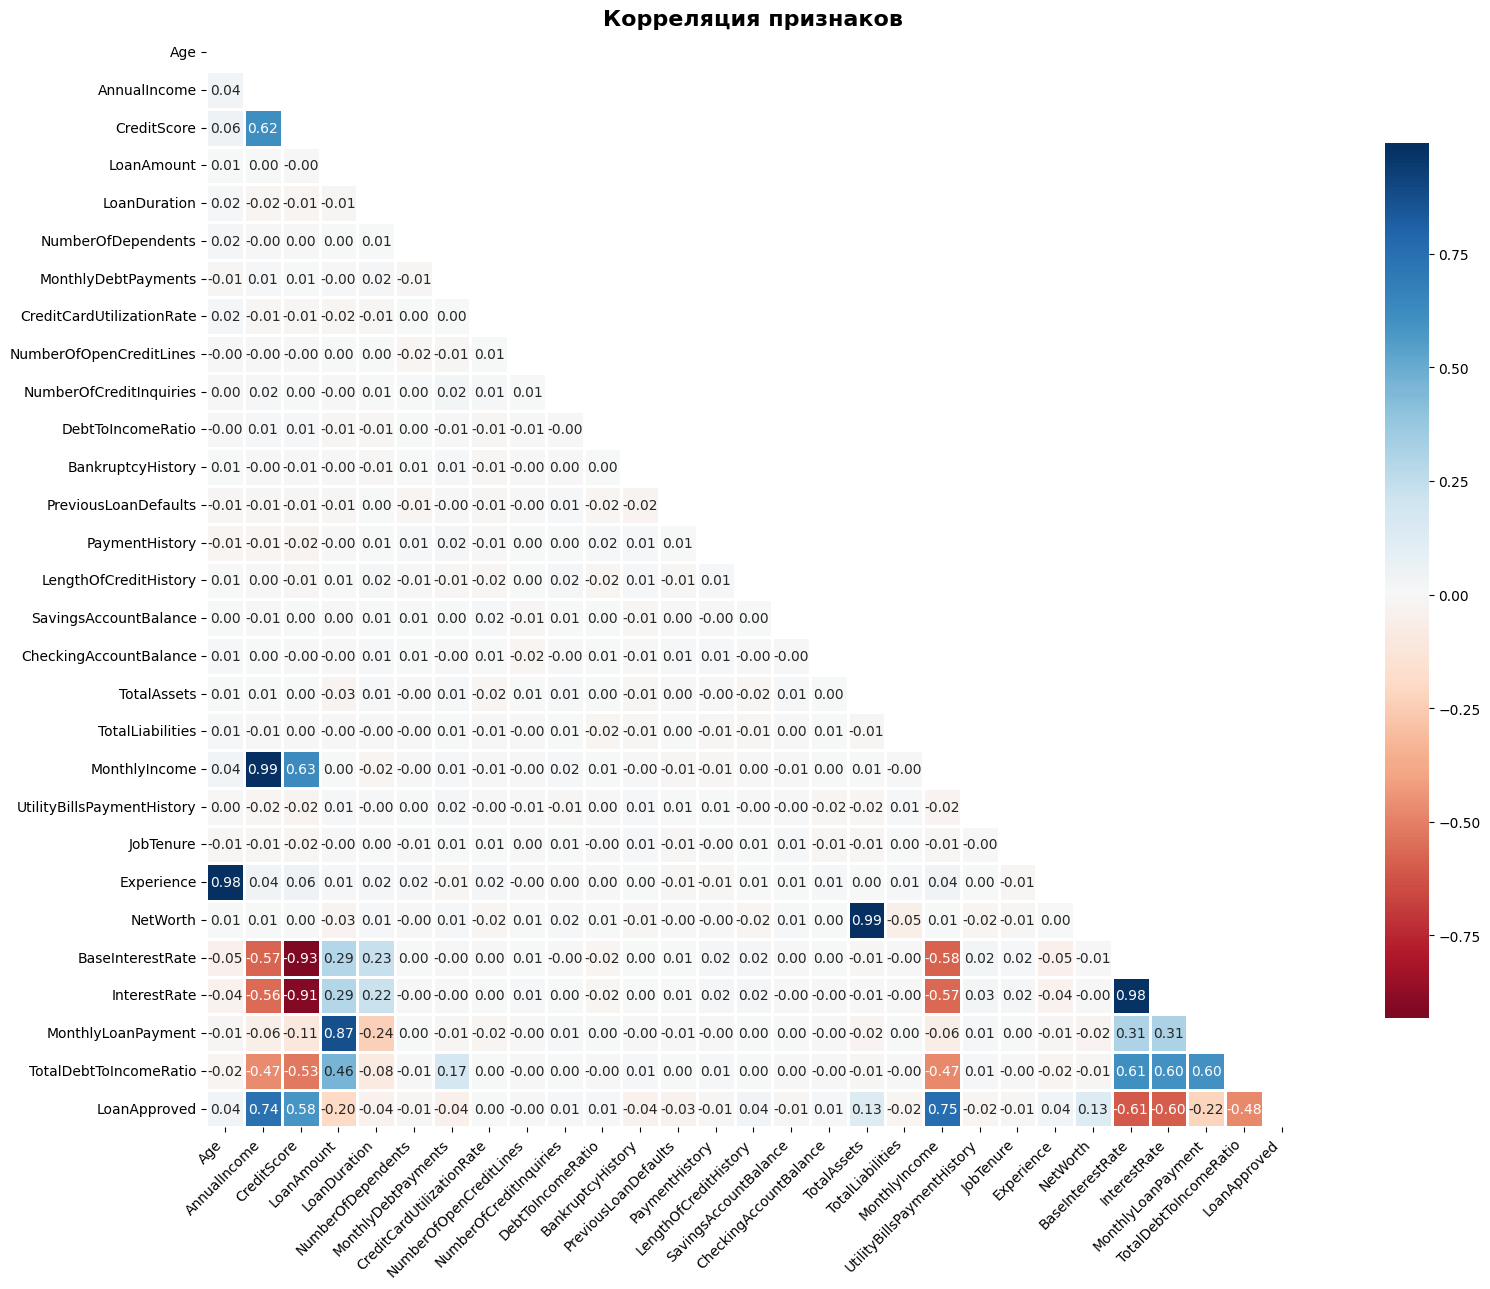

MonthlyIncome                 0.754853
AnnualIncome                  0.743034
CreditScore                   0.581812
NetWorth                      0.129624
TotalAssets                   0.129204
LengthOfCreditHistory         0.038509
Experience                    0.036699
Age                           0.036580
DebtToIncomeRatio             0.014922
NumberOfCreditInquiries       0.012520
CheckingAccountBalance        0.009503
CreditCardUtilizationRate     0.003731
NumberOfOpenCreditLines      -0.001003
NumberOfDependents           -0.007421
JobTenure                    -0.007951
PaymentHistory               -0.010064
SavingsAccountBalance        -0.011804
TotalLiabilities             -0.015154
UtilityBillsPaymentHistory   -0.020812
PreviousLoanDefaults         -0.029994
LoanDuration                 -0.039908
BankruptcyHistory            -0.042160
MonthlyDebtPayments          -0.044257
LoanAmount                   -0.195607
MonthlyLoanPayment           -0.217369
TotalDebtToIncomeRatio   

In [10]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(18, 13))
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr_matrix = train_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title('Корреляция признаков', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
target_corr = corr_matrix['LoanApproved'].drop('LoanApproved').sort_values(ascending=False)
print(target_corr)

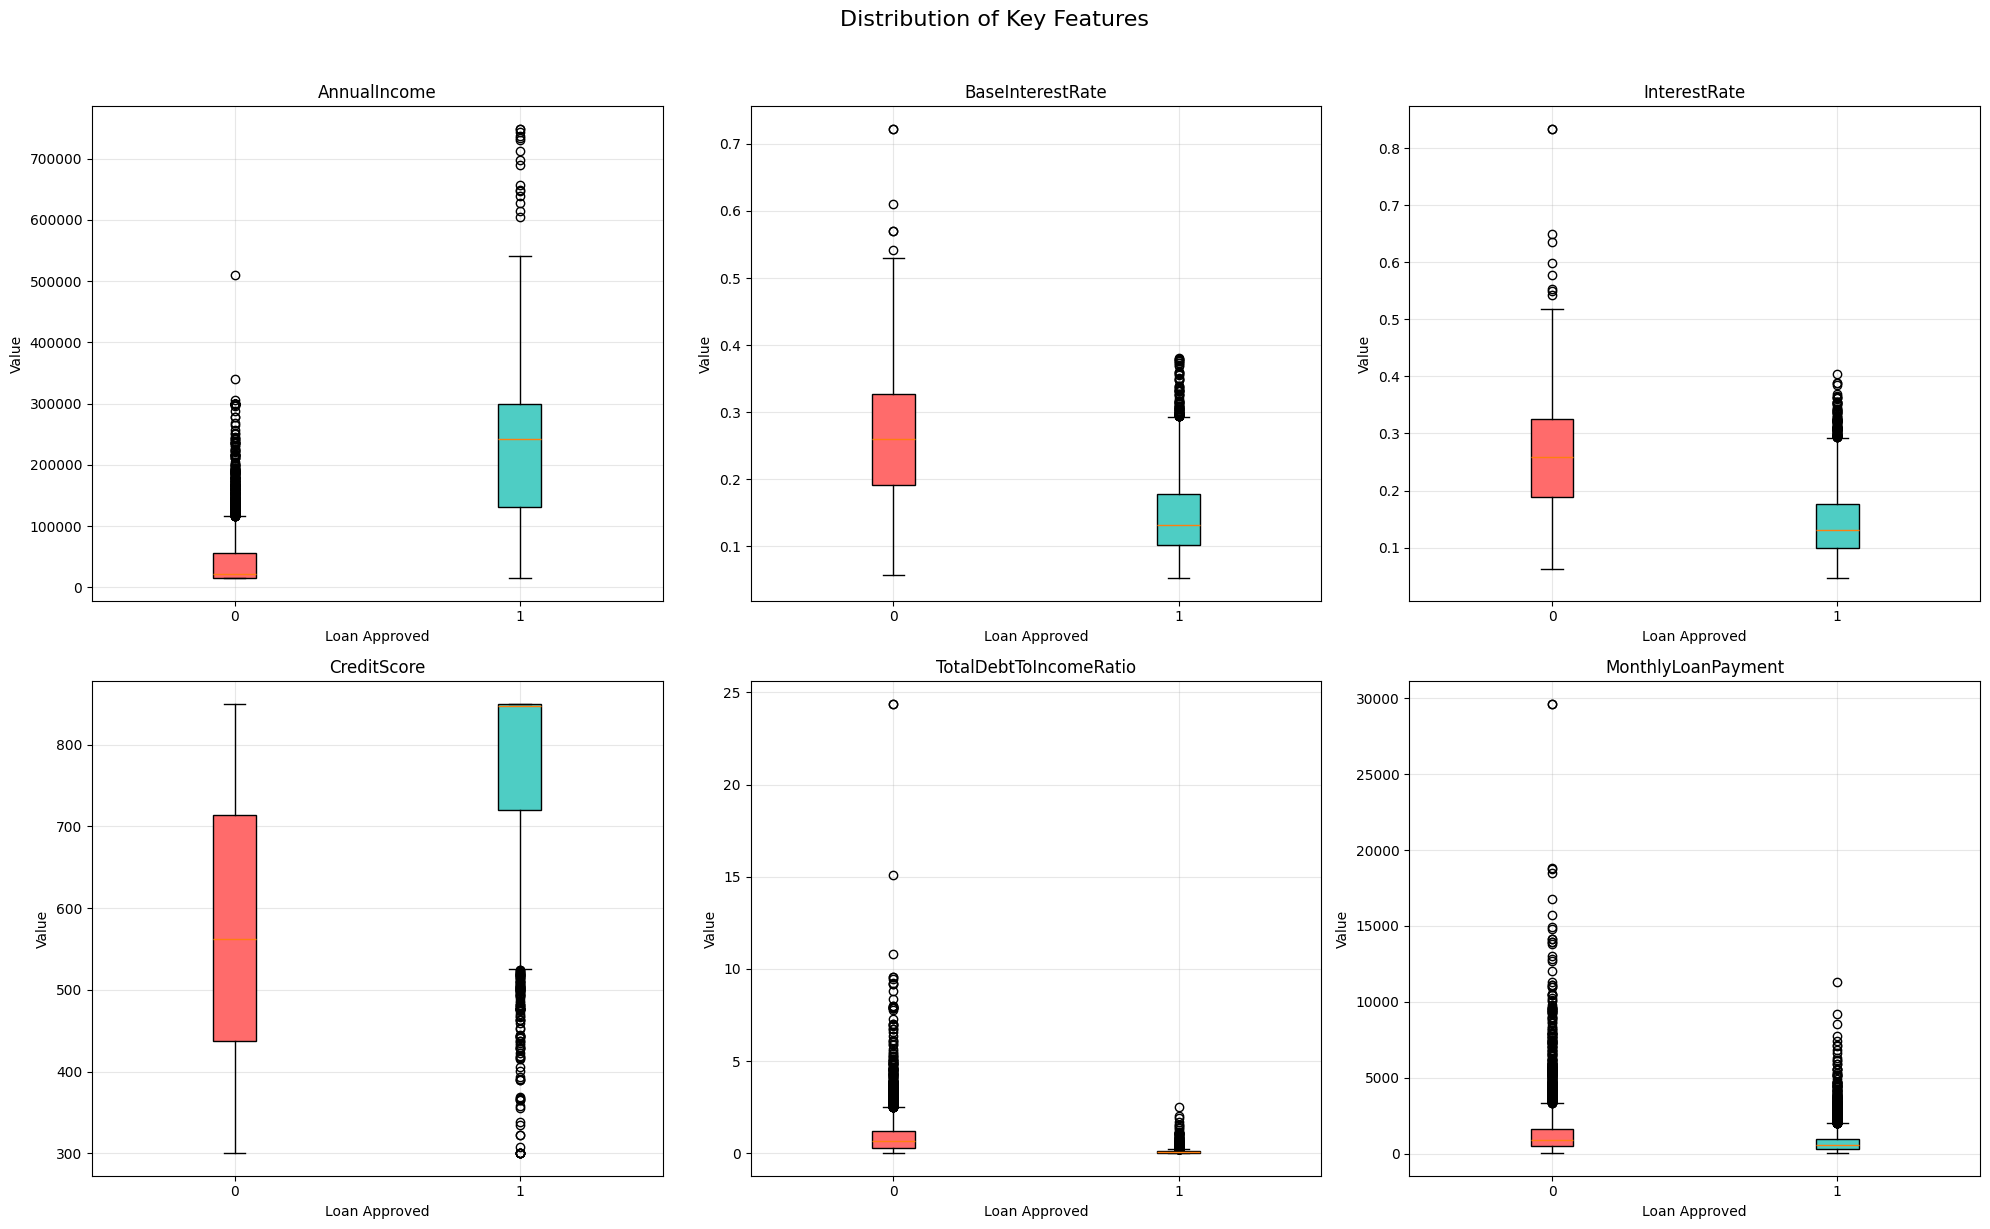

In [12]:
numeric_columns = train_df.select_dtypes(include=[np.number]).columns.drop('LoanApproved')
selected_features = target_corr.abs().sort_values(ascending=False)[1:7].index

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

colors = ['#FF6B6B', '#4ECDC4']
for i, feature in enumerate(selected_features):
    data_to_plot = [train_df[train_df['LoanApproved']==0][feature].dropna(), 
                    train_df[train_df['LoanApproved']==1][feature].dropna()]
    
    bp = axes[i].boxplot(data_to_plot, patch_artist=True, labels=['0', '1'])
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel('Loan Approved')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribution of Key Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
def feature_engineering(data, train_mode=True):
    data_clean = data.copy()
    
    if 'ID' in data_clean.columns:
        data_clean.drop('ID', axis=1, inplace=True)
    
    numeric_fields = data_clean.select_dtypes(include=[np.number]).columns
    for field in numeric_fields:
        missing_count = data_clean[field].isnull().sum()
        if missing_count > 0:
            fill_value = data_clean[field].median()
            data_clean[field].fillna(fill_value, inplace=True)
    
    categorical_fields = data_clean.select_dtypes(include=['object']).columns
    for field in categorical_fields:
        missing_count = data_clean[field].isnull().sum()
        if missing_count > 0:
            most_frequent = data_clean[field].mode()[0]
            data_clean[field].fillna(most_frequent, inplace=True)
    
    categorical_fields = data_clean.select_dtypes(include=['object']).columns
    if train_mode and 'LoanApproved' in categorical_fields:
        categorical_fields = [col for col in categorical_fields if col != 'LoanApproved']
    
    for field in categorical_fields:
        encoder = LabelEncoder()
        data_clean[field] = encoder.fit_transform(data_clean[field].astype(str))
    
    return data_clean

train_processed = feature_engineering(train_df, train_mode=True)
test_processed = feature_engineering(test_df, train_mode=False)

print(f"Training features count: {len(train_processed.columns)}")
print(f"Testing features count: {len(test_processed.columns)}")

X_train_full = train_processed.drop('LoanApproved', axis=1)
y_train_full = train_processed['LoanApproved']

print(f"\nTraining samples: {X_train_full.shape[0]}, Features: {X_train_full.shape[1]}")
print(f"Testing samples: {test_processed.shape[0]}, Features: {test_processed.shape[1]}")

feature_mismatch = X_train_full.shape[1] != test_processed.shape[1]
if feature_mismatch:
    print("WARNING: Feature count mismatch!")
else:
    print("✓ Feature dimensions match")

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.2, 
    random_state=123, 
    stratify=y_train_full
)

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_valid.shape}")
print(f"\nTarget distribution in training:")
print(y_train.value_counts().sort_index())

Training features count: 35
Testing features count: 34

Training samples: 11017, Features: 34
Testing samples: 5000, Features: 34
✓ Feature dimensions match

Training set: (8813, 34)
Validation set: (2204, 34)

Target distribution in training:
LoanApproved
0.0    4096
1.0    4717
Name: count, dtype: int64


In [14]:
class CustomBaggingClassifier:
    def __init__(self, base_estimator=None, n_estimators=10, max_samples=1.0, random_state=None):
        self.base_estimator = base_estimator if base_estimator else DecisionTreeClassifier()
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.random_state = random_state
        self.estimators_ = []
        self.samples_indices_ = []
        
    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples = int(len(X) * self.max_samples)
        
        X_array = X.values if hasattr(X, 'values') else X
        y_array = y.values if hasattr(y, 'values') else y
        
        self.estimators_ = []
        self.samples_indices_ = []
        
        for i in range(self.n_estimators):
            indices = np.random.choice(len(X_array), size=n_samples, replace=True)
            self.samples_indices_.append(indices)
            
            estimator = self._clone_estimator()
            estimator.fit(X_array[indices], y_array[indices])
            self.estimators_.append(estimator)
            
        return self
    
    def _clone_estimator(self):
        from sklearn.base import clone
        return clone(self.base_estimator)
    
    def predict_proba(self, X):
        X_array = X.values if hasattr(X, 'values') else X
        
        predictions = np.array([est.predict_proba(X_array) for est in self.estimators_])
        
        return np.mean(predictions, axis=0)
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] > 0.5).astype(int)

In [16]:
ensemble_1 = CustomBaggingClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=123),
    n_estimators=100,
    max_samples=0.85,
    random_state=123
)
ensemble_1.fit(X_train, y_train)

pred_1 = ensemble_1.predict(X_valid)
proba_1 = ensemble_1.predict_proba(X_valid)[:, 1]

ensemble_2 = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=123),
    n_estimators=100,
    max_samples=0.85,
    bootstrap=True,
    random_state=123,
    n_jobs=-1
)
ensemble_2.fit(X_train, y_train)

pred_2 = ensemble_2.predict(X_valid)
proba_2 = ensemble_2.predict_proba(X_valid)[:, 1]

print("="*50)
print("CUSTOM IMPLEMENTATION RESULTS")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_valid, pred_1):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_valid, proba_1):.4f}")
print(f"Precision: {precision_score(y_valid, pred_1):.4f}")
print(f"Recall:    {recall_score(y_valid, pred_1):.4f}")
print(f"F1-Score:  {f1_score(y_valid, pred_1):.4f}")

print("\n" + "="*50)
print("SKLEARN IMPLEMENTATION RESULTS")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_valid, pred_2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_valid, proba_2):.4f}")
print(f"Precision: {precision_score(y_valid, pred_2):.4f}")
print(f"Recall:    {recall_score(y_valid, pred_2):.4f}")
print(f"F1-Score:  {f1_score(y_valid, pred_2):.4f}")
print("="*50)

CUSTOM IMPLEMENTATION RESULTS
Accuracy:  0.9238
ROC-AUC:   0.9809
Precision: 0.9210
Recall:    0.9381
F1-Score:  0.9295

SKLEARN IMPLEMENTATION RESULTS
Accuracy:  0.9265
ROC-AUC:   0.9809
Precision: 0.9235
Recall:    0.9407
F1-Score:  0.9320


In [22]:
model_performance = {}

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_valid)
gb_proba = gb_model.predict_proba(X_valid)[:, 1]

model_performance['GradientBoosting'] = {
    'accuracy': accuracy_score(y_valid, gb_pred),
    'roc_auc': roc_auc_score(y_valid, gb_proba),
    'precision': precision_score(y_valid, gb_pred),
    'recall': recall_score(y_valid, gb_pred),
    'f1': f1_score(y_valid, gb_pred),
    'model': gb_model
}

lgbm_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_valid)
lgbm_proba = lgbm_model.predict_proba(X_valid)[:, 1]

model_performance['LightGBM'] = {
    'accuracy': accuracy_score(y_valid, lgbm_pred),
    'roc_auc': roc_auc_score(y_valid, lgbm_proba),
    'precision': precision_score(y_valid, lgbm_pred),
    'recall': recall_score(y_valid, lgbm_pred),
    'f1': f1_score(y_valid, lgbm_pred),
    'model': lgbm_model
}

xgboost_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)
xgboost_model.fit(X_train, y_train)
xgboost_pred = xgboost_model.predict(X_valid)
xgboost_proba = xgboost_model.predict_proba(X_valid)[:, 1]

model_performance['XGBoost'] = {
    'accuracy': accuracy_score(y_valid, xgboost_pred),
    'roc_auc': roc_auc_score(y_valid, xgboost_proba),
    'precision': precision_score(y_valid, xgboost_pred),
    'recall': recall_score(y_valid, xgboost_pred),
    'f1': f1_score(y_valid, xgboost_pred),
    'model': xgboost_model
}

catboost_model = cb.CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=3,
    random_state=42,
    verbose=0
)
catboost_model.fit(X_train, y_train)
catboost_pred = catboost_model.predict(X_valid)
catboost_proba = catboost_model.predict_proba(X_valid)[:, 1]

model_performance['CatBoost'] = {
    'accuracy': accuracy_score(y_valid, catboost_pred),
    'roc_auc': roc_auc_score(y_valid, catboost_proba),
    'precision': precision_score(y_valid, catboost_pred),
    'recall': recall_score(y_valid, catboost_pred),
    'f1': f1_score(y_valid, catboost_pred),
    'model': catboost_model
}

results_df = pd.DataFrame(model_performance).T
results_df = results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
print(results_df.round(4))

best_model_idx = results_df['roc_auc'].argmax()
best_model_name = results_df.index[best_model_idx]
print(f"\nBest model: {best_model_name} (ROC-AUC: {results_df.loc[best_model_name, 'roc_auc']:.4f})")

                  accuracy precision    recall        f1   roc_auc
GradientBoosting  0.926044  0.928391  0.933898  0.931136  0.982913
LightGBM          0.923775  0.928088  0.929661  0.928874  0.982982
XGBoost           0.926497  0.927731  0.935593  0.931646  0.983302
CatBoost          0.926497  0.926298  0.937288  0.931761  0.982388

Best model: XGBoost (ROC-AUC: 0.9833)


In [29]:
from sklearn.model_selection import train_test_split


if 'X' not in dir() or 'y' not in dir():
    X = train_processed.drop('LoanApproved', axis=1)
    y = train_processed['LoanApproved']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 60, 280),
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.28, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'num_leaves': trial.suggest_int('num_leaves', 25, 95),
        'min_child_samples': trial.suggest_int('min_child_samples', 8, 45),
        'subsample': trial.suggest_float('subsample', 0.65, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 0.8, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 0.8, log=True),
        'random_state': 42,
        'verbose': -1
    }
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_val)[:, 1]  # Теперь X_val существует!
    roc_auc = roc_auc_score(y_val, y_proba)
    
    return roc_auc

study = optuna.create_study(
    direction='maximize', 
    study_name='loan_approval_opt'
)
study.optimize(objective, n_trials=45, show_progress_bar=True)

print(f"Лучший ROC-AUC: {study.best_value:.4f}")
print(f"\nЛучшие гиперпараметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['verbose'] = -1

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_val)
y_proba_final = final_model.predict_proba(X_val)[:, 1]

print(f"\nAccuracy:  {accuracy_score(y_val, y_pred_final):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_proba_final):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_final):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_pred_final):.4f}")

[I 2026-02-26 21:12:58,617] A new study created in memory with name: loan_approval_opt


X_train shape: (8813, 34)
X_val shape: (2204, 34)
y_train shape: (8813,)
y_val shape: (2204,)


  0%|          | 0/45 [00:00<?, ?it/s]

[I 2026-02-26 21:12:59,404] Trial 0 finished with value: 0.9839463056144067 and parameters: {'n_estimators': 267, 'learning_rate': 0.09117961467492597, 'max_depth': 9, 'num_leaves': 30, 'min_child_samples': 44, 'subsample': 0.7235827251406372, 'colsample_bytree': 0.8533283302308331, 'reg_alpha': 9.719877937744815e-07, 'reg_lambda': 5.5020001429638056e-08}. Best is trial 0 with value: 0.9839463056144067.
[I 2026-02-26 21:12:59,825] Trial 1 finished with value: 0.9833587129237289 and parameters: {'n_estimators': 273, 'learning_rate': 0.04646801536852978, 'max_depth': 4, 'num_leaves': 80, 'min_child_samples': 40, 'subsample': 0.6528942027230571, 'colsample_bytree': 0.7813529564791977, 'reg_alpha': 0.012185636802051024, 'reg_lambda': 0.00025853809210813107}. Best is trial 0 with value: 0.9839463056144067.
[I 2026-02-26 21:12:59,964] Trial 2 finished with value: 0.9825948424258474 and parameters: {'n_estimators': 87, 'learning_rate': 0.2454742646984739, 'max_depth': 3, 'num_leaves': 45, 'mi

In [30]:
def calculate_accuracy(true_labels, predicted_labels):
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)
    
    correct_predictions = np.sum(true_labels == predicted_labels)
    total_predictions = len(true_labels)
    
    accuracy_value = correct_predictions / total_predictions
    return accuracy_value


test_predictions = final_model.predict(X_val)
manual_accuracy = calculate_accuracy(y_val, test_predictions)
library_accuracy = accuracy_score(y_val, test_predictions)

print(f"Manual implementation: {manual_accuracy:.6f}")
print(f"Sklearn implementation: {library_accuracy:.6f}")
print(f"Difference: {abs(manual_accuracy - library_accuracy):.10f}")

Manual implementation: 0.931034
Sklearn implementation: 0.931034
Difference: 0.0000000000


In [31]:
def manual_precision(actual, predicted, positive_class=1):
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    true_positives = np.sum((actual == positive_class) & (predicted == positive_class))
    false_positives = np.sum((actual != positive_class) & (predicted == positive_class))
    
    denominator = true_positives + false_positives
    precision_value = true_positives / denominator if denominator > 0 else 0.0
    
    return precision_value

if 'y_pred_test' not in dir():
    y_pred_test = final_model.predict(X_val)

manual_result = manual_precision(y_val, y_pred_test)
sklearn_result = precision_score(y_val, y_pred_test)

print("=" * 45)
print("PRECISION COMPARISON")
print("=" * 45)
print(f"Manual precision:    {manual_result:.6f}")
print(f"Scikit-learn precision: {sklearn_result:.6f}")
print(f"Difference:          {abs(manual_result - sklearn_result):.10f}")
print("=" * 45)

PRECISION COMPARISON
Manual precision:    0.930486
Scikit-learn precision: 0.930486
Difference:          0.0000000000


In [33]:
def compute_recall(ground_truth, predictions, target_class=1):
    ground_truth = np.array(ground_truth)
    predictions = np.array(predictions)
    
    true_positives = np.sum((ground_truth == target_class) & (predictions == target_class))
    false_negatives = np.sum((ground_truth == target_class) & (predictions != target_class))
    
    total_positives = true_positives + false_negatives
    recall_value = true_positives / total_positives if total_positives > 0 else 0.0
    
    return recall_value

recall_manual = compute_recall(y_val, y_pred_test)
recall_sklearn = recall_score(y_val, y_pred_test)

print("=" * 45)
print("RECALL COMPARISON")
print("=" * 45)
print(f"Manual calculation:  {recall_manual:.6f}")
print(f"Sklearn calculation: {recall_sklearn:.6f}")
print(f"Difference:          {abs(recall_manual - recall_sklearn):.10f}")
print("=" * 45)

RECALL COMPARISON
Manual calculation:  0.941525
Sklearn calculation: 0.941525
Difference:          0.0000000000


In [34]:
def calculate_f1(actual, predicted, positive=1):
    prec = manual_precision(actual, predicted, positive)
    rec = compute_recall(actual, predicted, positive)
    
    denominator = prec + rec
    if denominator == 0:
        return 0.0
    
    f1_value = 2 * (prec * rec) / denominator
    return f1_value

f1_manual = calculate_f1(y_val, y_pred_test)
f1_sklearn = f1_score(y_val, y_pred_test)

print("=" * 45)
print("F1-SCORE COMPARISON")
print("=" * 45)
print(f"Manual F1:     {f1_manual:.6f}")
print(f"Sklearn F1:    {f1_sklearn:.6f}")
print(f"Difference:    {abs(f1_manual - f1_sklearn):.10f}")
print("=" * 45)

F1-SCORE COMPARISON
Manual F1:     0.935973
Sklearn F1:    0.935973
Difference:    0.0000000000


In [35]:
def compute_auc(ground_truth, probabilities):
    ground_truth = np.array(ground_truth)
    probabilities = np.array(probabilities)
    
    sorted_idx = np.argsort(probabilities)[::-1]
    sorted_truth = ground_truth[sorted_idx]
    
    positive_count = np.sum(sorted_truth == 1)
    negative_count = np.sum(sorted_truth == 0)
    
    if positive_count == 0 or negative_count == 0:
        return 0.5
    
    true_positive_rate = []
    false_positive_rate = []
    
    tp_cum = 0
    fp_cum = 0
    
    for value in sorted_truth:
        if value == 1:
            tp_cum += 1
        else:
            fp_cum += 1
        
        true_positive_rate.append(tp_cum / positive_count)
        false_positive_rate.append(fp_cum / negative_count)
    
    true_positive_rate = [0] + true_positive_rate
    false_positive_rate = [0] + false_positive_rate
    
    area = 0.0
    for idx in range(1, len(false_positive_rate)):
        width = false_positive_rate[idx] - false_positive_rate[idx-1]
        avg_height = (true_positive_rate[idx] + true_positive_rate[idx-1]) / 2
        area += width * avg_height
    
    return area

predicted_probs = final_model.predict_proba(X_val)[:, 1]

manual_auc = compute_auc(y_val, predicted_probs)
library_auc = roc_auc_score(y_val, predicted_probs)

print("=" * 50)
print("ROC-AUC COMPARISON")
print("=" * 50)
print(f"Manual calculation:  {manual_auc:.6f}")
print(f"Sklearn calculation: {library_auc:.6f}")
print(f"Difference:          {abs(manual_auc - library_auc):.8f}")
print("=" * 50)

ROC-AUC COMPARISON
Manual calculation:  0.983946
Sklearn calculation: 0.983946
Difference:          0.00000000


In [36]:
def calculate_pr_auc(actual_values, predicted_probs):
    actual_values = np.array(actual_values)
    predicted_probs = np.array(predicted_probs)
    
    sorted_idx = np.argsort(predicted_probs)[::-1]
    sorted_actual = actual_values[sorted_idx]
    
    total_positives = np.sum(sorted_actual == 1)
    
    if total_positives == 0:
        return 0.0
    
    precisions = []
    recalls = []
    
    true_pos = 0
    false_pos = 0
    
    for value in sorted_actual:
        if value == 1:
            true_pos += 1
        else:
            false_pos += 1
        
        current_precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
        current_recall = true_pos / total_positives
        
        precisions.append(current_precision)
        recalls.append(current_recall)
    
    sort_by_recall = np.argsort(recalls)
    recalls_sorted = np.array(recalls)[sort_by_recall]
    precisions_sorted = np.array(precisions)[sort_by_recall]
    
    pr_area = 0.0
    for idx in range(1, len(recalls_sorted)):
        recall_diff = recalls_sorted[idx] - recalls_sorted[idx-1]
        avg_precision = (precisions_sorted[idx] + precisions_sorted[idx-1]) / 2
        pr_area += recall_diff * avg_precision
    
    return pr_area

from sklearn.metrics import average_precision_score

model_probs = final_model.predict_proba(X_val)[:, 1]

manual_pr_auc = calculate_pr_auc(y_val, model_probs)
sklearn_pr_auc = average_precision_score(y_val, model_probs)

print("=" * 50)
print("PR-AUC COMPARISON")
print("=" * 50)
print(f"Manual PR-AUC:    {manual_pr_auc:.6f}")
print(f"Sklearn PR-AUC:   {sklearn_pr_auc:.6f}")
print(f"Difference:       {abs(manual_pr_auc - sklearn_pr_auc):.8f}")
print("=" * 50)

PR-AUC COMPARISON
Manual PR-AUC:    0.986077
Sklearn PR-AUC:   0.986922
Difference:       0.00084474


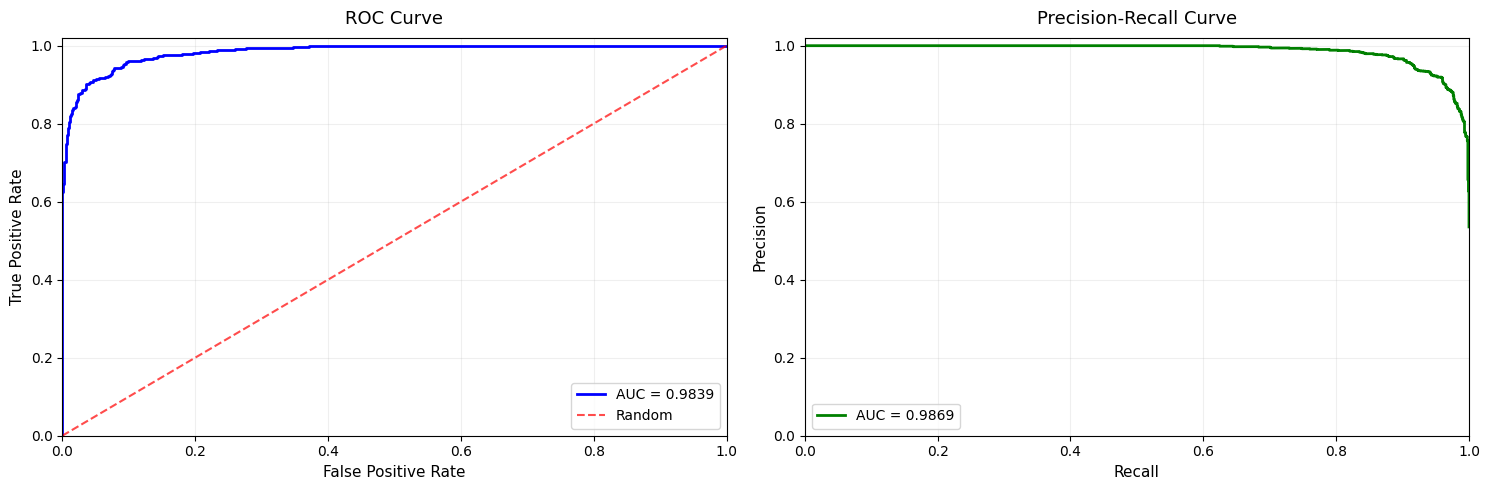

In [39]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Получаем вероятности если еще нет
if 'y_proba_test' not in dir():
    y_proba_test = final_model.predict_proba(X_val)[:, 1]

false_pos, true_pos, _ = roc_curve(y_val, y_proba_test)
roc_area = auc(false_pos, true_pos)

prec_vals, rec_vals, _ = precision_recall_curve(y_val, y_proba_test)
pr_area = auc(rec_vals, prec_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(false_pos, true_pos, 'b-', linewidth=2, label=f'AUC = {roc_area:.4f}')
ax1.plot([0, 1], [0, 1], 'r--', linewidth=1.5, alpha=0.7, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve', fontsize=13, pad=10)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.2)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1.02)

ax2.plot(rec_vals, prec_vals, 'g-', linewidth=2, label=f'AUC = {pr_area:.4f}')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curve', fontsize=13, pad=10)
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.2)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

In [42]:
X_test = test_processed

test_predictions = final_model.predict_proba(X_test)[:, 1]

# Правильный путь к файлу
data_path = '/kaggle/input/mai-ml-lab-2-fiit-2025'
test_df_original = pd.read_csv(f'{data_path}/test_c.csv')

if 'ID' in test_df_original.columns:
    submission = pd.DataFrame({
        'ID': test_df_original['ID'],
        'LoanApproved': test_predictions
    })
else:
    submission = pd.DataFrame({
        'id': range(len(test_predictions)),
        'LoanApproved': test_predictions
    })

# Сохраняем в working директорию (оттуда можно скачать)
submission.to_csv('/kaggle/working/submission.csv', index=False)

print(f"\nПервые строки submission:")
print(submission.head(10))
print(f"\nСтатистика предсказаний:")
print(f"  Мин: {test_predictions.min():.4f}")
print(f"  Макс: {test_predictions.max():.4f}")
print(f"  Среднее: {test_predictions.mean():.4f}")
print(f"\nФайл сохранен: /kaggle/working/submission.csv")


Первые строки submission:
   ID  LoanApproved
0   0      0.999468
1   1      0.000835
2   2      0.999813
3   3      0.999747
4   4      0.999943
5   5      0.000142
6   6      0.999994
7   7      0.999721
8   8      0.698373
9   9      0.000005

Статистика предсказаний:
  Мин: 0.0000
  Макс: 1.0000
  Среднее: 0.5219

Файл сохранен: /kaggle/working/submission.csv
